# Enhanced Customer Lifetime Value Prediction

In [11]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from datetime import datetime

In [12]:
# Load and preprocess data
df = pd.read_csv('synthetic_customer_transactions.csv')
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y')
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], format='%d-%m-%Y')

In [13]:
# Cutoff for historical vs future CLV
cutoff_date = pd.to_datetime('2022-12-31')
historical = df[df['Transaction_Date'] < cutoff_date]
future = df[df['Transaction_Date'] >= cutoff_date]

In [14]:
# RFM + Tenure features
features = historical.groupby('CustomerID').agg({
    'Transaction_Date': [
        lambda x: (cutoff_date - x.max()).days,
        lambda x: x.count(),
        lambda x: (cutoff_date - x.min()).days
    ],
    'TotalPrice': 'sum'
})
features.columns = ['Recency', 'Frequency', 'Tenure', 'Monetary']
features = features.reset_index()

In [15]:
# Target variable
target = future.groupby('CustomerID')['TotalPrice'].sum().reset_index()
target.columns = ['CustomerID', 'CLV']
data = pd.merge(features, target, on='CustomerID', how='inner')

In [16]:
# Add demographic data
customer_info = df.drop_duplicates('CustomerID')[['CustomerID', 'Region', 'Gender', 'Age', 'Customer_Segment']]
data = pd.merge(data, customer_info, on='CustomerID', how='left')
data = pd.get_dummies(data, columns=['Region', 'Gender', 'Customer_Segment'], drop_first=True)

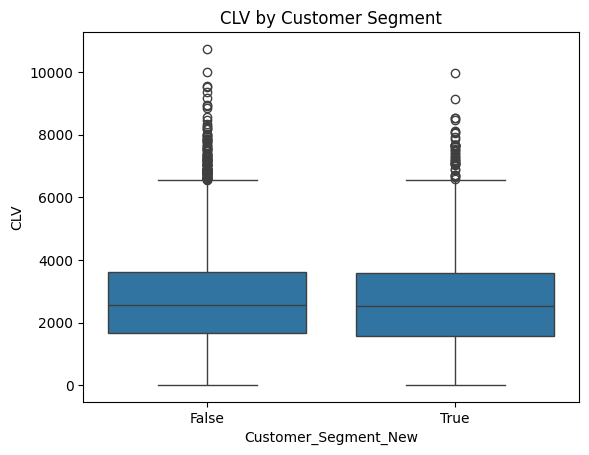

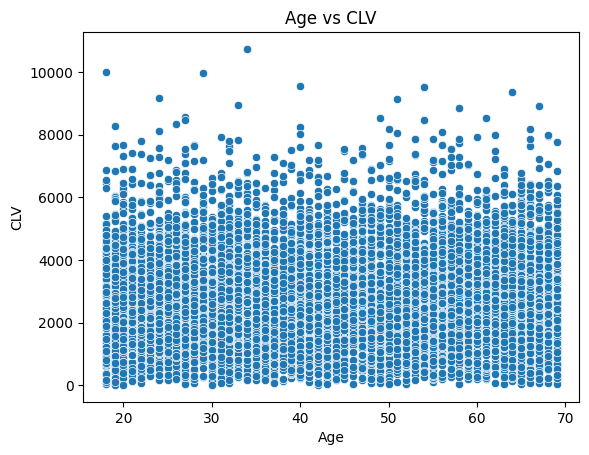

In [17]:
# EDA visualizations
sns.boxplot(x='Customer_Segment_New', y='CLV', data=data)
plt.title('CLV by Customer Segment')
plt.show()

sns.scatterplot(x='Age', y='CLV', data=data)
plt.title('Age vs CLV')
plt.show()

In [18]:
# Split and model
X = data.drop(['CustomerID', 'CLV'], axis=1)
y = data['CLV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Model comparison
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(),
    'LightGBM': lgb.LGBMRegressor()
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }
pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 7962, number of used features: 13
[LightGBM] [Info] Start training from score 2729.613068


,MAE,RMSE,R2
LinearRegression,1162.918128,1471.110612,-0.005147
DecisionTree,1656.619141,2121.728858,-1.090830
RandomForest,1189.063083,1507.975692,-0.056155
XGBoost,1233.851090,1571.386629,-0.146846
LightGBM,1182.034277,1499.814733,-0.044754


In [20]:
# Hyperparameter tuning: Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(), param_grid_rf, cv=3, scoring='neg_mean_squared_error')
grid_rf.fit(X_train, y_train)
grid_rf.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

In [21]:
# Hyperparameter tuning: LightGBM
param_grid_lgb = {
    'num_leaves': [31, 50],
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.05]
}
grid_lgb = GridSearchCV(lgb.LGBMRegressor(), param_grid_lgb, cv=3, scoring='neg_mean_squared_error')
grid_lgb.fit(X_train, y_train)
grid_lgb.best_params_

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 5308, number of used features: 13
[LightGBM] [Info] Start training from score 2719.619639
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 812
[LightGBM] [Info] Number of data points in the train set: 5308, number of used features: 13
[LightGBM] [Info] Start training from score 2719.073438
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total 

{'learning_rate': 0.05, 'n_estimators': 50, 'num_leaves': 31}